In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

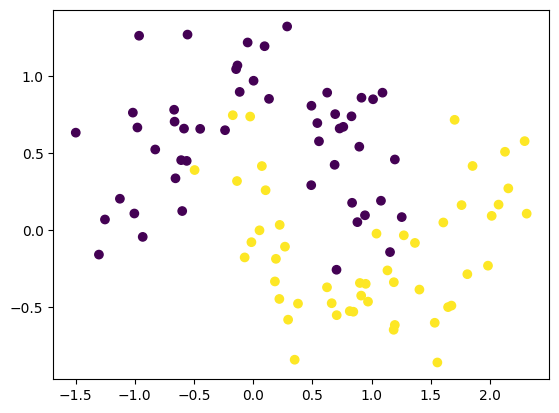

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17,025
Trainable params: 17,025
Non-trainable params: 0
_________________________________________________________________


In [5]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 [==============================] - 12s 1ms/step


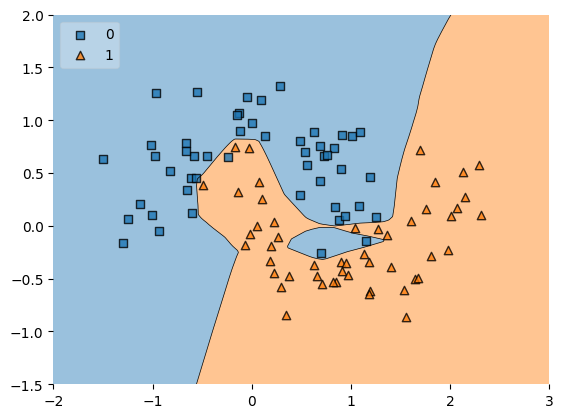

In [6]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

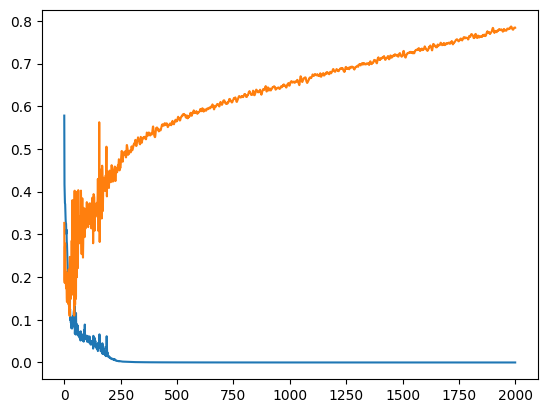

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

# Regularization

### L2 - Mostly (99%) used regularization technique

In [8]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.3)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.3)))
model2.add(Dense(1, activation="sigmoid"))

model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               384       
                                                                 
 dense_4 (Dense)             (None, 128)               16512     
                                                                 
 dense_5 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17,025
Trainable params: 17,025
Non-trainable params: 0
_________________________________________________________________


In [9]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 [==============================] - 12s 1ms/step


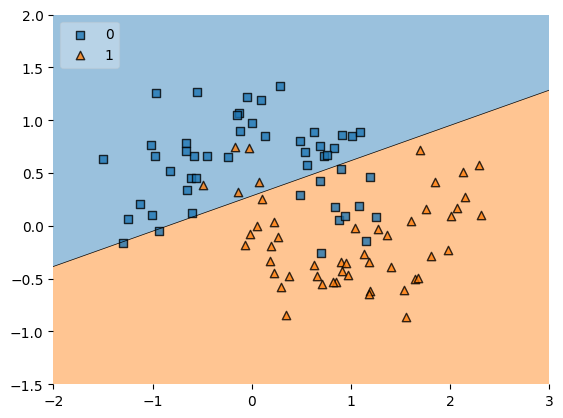

In [10]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

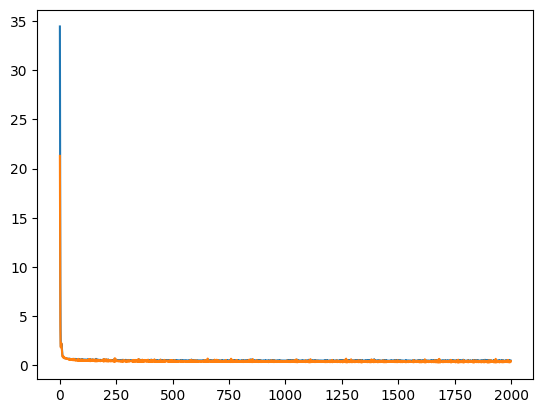

In [11]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [12]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

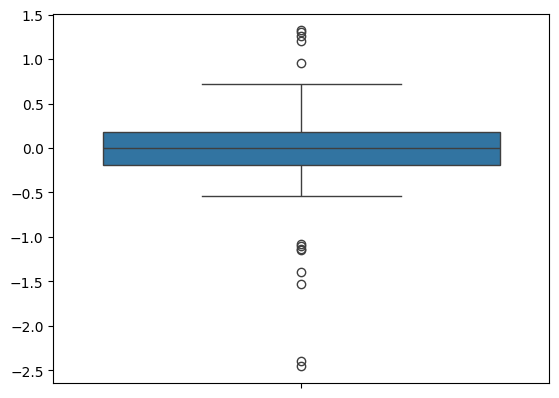

In [13]:
sns.boxplot(model1_weight_layer1)

<Axes: >

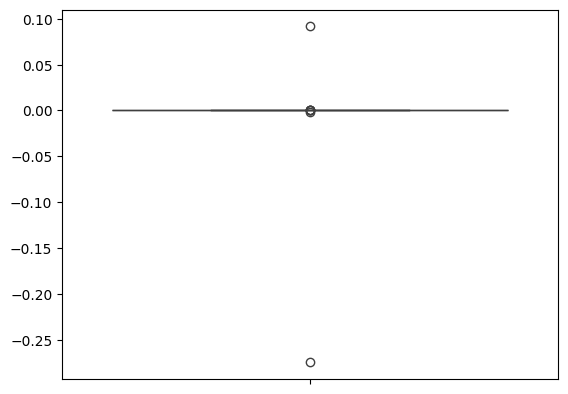

In [14]:
sns.boxplot(model2_weight_layer1)

In [15]:
model1_weight_layer1.min()

-2.456775

In [16]:
model1_weight_layer1.max()

1.3232621

In [17]:
# Before regularization - weights value vary between -2.5 to 1.6

In [18]:
model2_weight_layer1.min()

-0.27476883

In [19]:
model2_weight_layer1.max()

0.091774285

In [20]:
# After regularization - weights value vary between -0.09 to 0.25
# Values comes closer to zero after regularization

<Axes: ylabel='Density'>

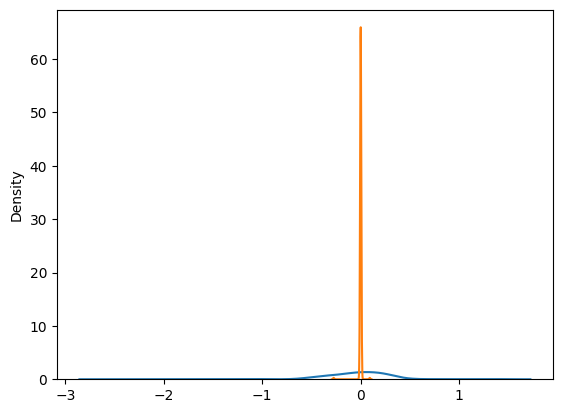

In [21]:
sns.kdeplot(model1_weight_layer1)
sns.kdeplot(model2_weight_layer1)

In [22]:
# After regularization there is great improvement in the model performance.

### L1 Regularization

In [23]:
model3 = Sequential()

model3.add(Dense(256,input_dim=2,activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.01)))
model3.add(Dense(256,activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.01)))
model3.add(Dense(1,activation="sigmoid"))

model3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 256)               768       
                                                                 
 dense_7 (Dense)             (None, 256)               65792     
                                                                 
 dense_8 (Dense)             (None, 1)                 257       
                                                                 
Total params: 66,817
Trainable params: 66,817
Non-trainable params: 0
_________________________________________________________________


In [24]:
adam = Adam(learning_rate=0.01)
model3.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history3 = model3.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 [==============================] - 14s 1ms/step


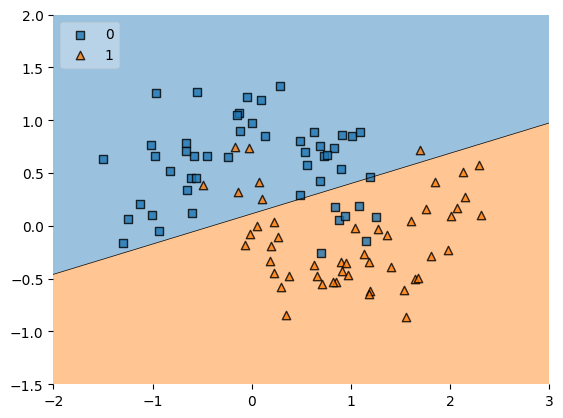

In [26]:
plot_decision_regions(X, y.astype('int'), clf=model3, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

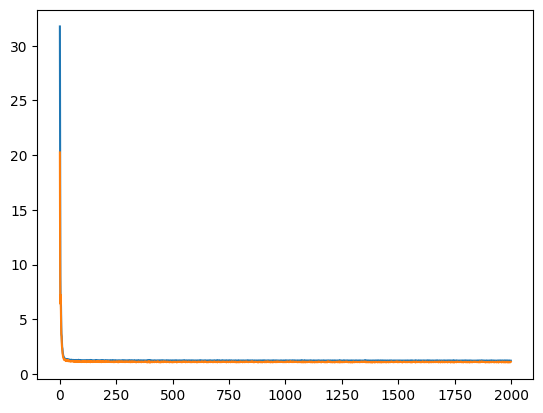

In [25]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])

In [37]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)
model3_weight_layer1 = model3.get_weights()[0].reshape(512)

In [42]:
model1_weight_layer1.min()

-2.456775

In [43]:
model1_weight_layer1.max()

1.3232621

In [44]:
model3_weight_layer1.min()

-0.7643563

In [45]:
model3_weight_layer1.max()

0.21916935

<Axes: >

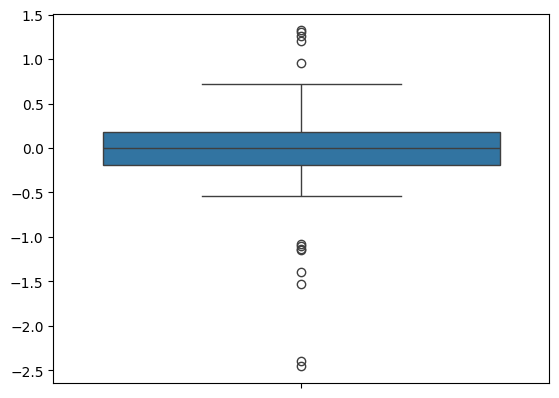

In [38]:
sns.boxplot(model1_weight_layer1)

<Axes: >

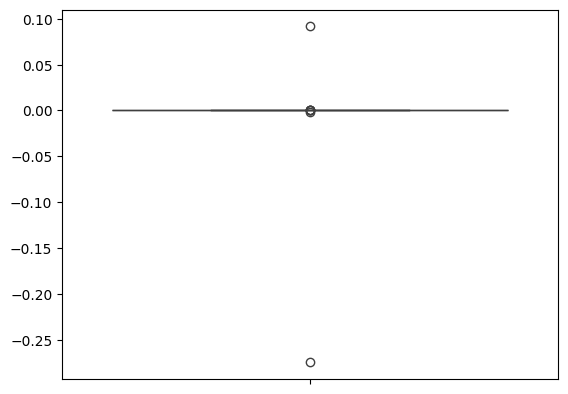

In [39]:
sns.boxplot(model2_weight_layer1)

<Axes: >

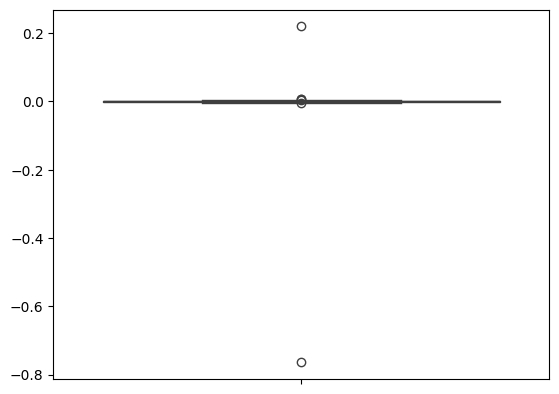

In [40]:
sns.boxplot(model3_weight_layer1)

<Axes: ylabel='Density'>

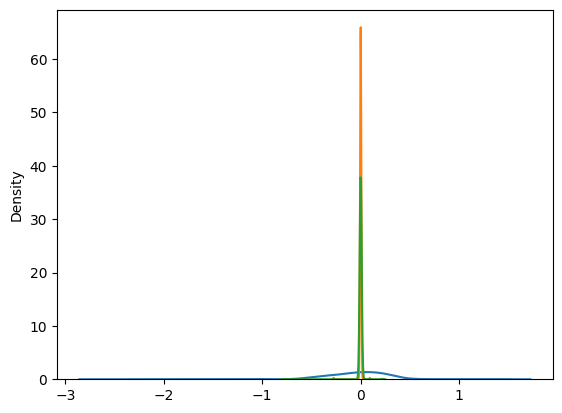

In [41]:
sns.kdeplot(model1_weight_layer1)
sns.kdeplot(model2_weight_layer1)
sns.kdeplot(model3_weight_layer1)